In [1]:
import pandas as pd
from pathlib import Path
import json
from tqdm.rich import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import skew, kurtosis

colors = ["#F0741E", "#276CB3"]

plt.style.use("seaborn-v0_8-paper")

save_path=Path("./plots")
save_path.mkdir(exist_ok=True, parents=True)

In [2]:
def get_num_atoms(file_xyz):
    try:
        with open(file_xyz, 'r') as file:
            first_line = file.readline()
            n_atoms = int(first_line.strip())
            return n_atoms
    except Exception as e:
        print(f"Error: {e}")
        return None

In [3]:
names = []
n_electrons = []
n_atoms = []
fermi = []
total_energy = []
IP =[]
EA =[]
bang_gap = []
total_energy_plus = []
total_energy_minuns = []
current = []
batch_id = []

xyz_files_path = Path("/home/tommaso/xyz_files_G")

batches = [2,3,4,5,6,7,8]
for batch in batches:
    dataset = Path(f"/home/tommaso/git_workspace/AutoDFTB/data_batch_{batch}")

    dftb_files = [f for f in dataset.joinpath("dftb","json_files").iterdir() if f.suffix.lower() ==".json"]

    for file in tqdm(dftb_files):
        with open(str(file),"r") as f:
            data = json.load(f)
        
        try:
            with open(str(dataset.joinpath("transport","transport_output",f"{data['file_name'][:-4]}_e.json")),"r") as f:
                data_current = json.load(f)
            current.append(data_current["current"])
            
        except:
            continue
        
        names.append(data["file_name"][:-4])
        n_electrons.append(data["n_electrons"])
        fermi.append(data["fermi_level_ev"])
        total_energy.append(data["total_energy_eV"])
        IP.append(data["EA_ev"])
        EA.append(data["IP_ev"])
        bang_gap.append(data["band_gap_ev"])
        total_energy_plus.append(data["total_energy_eV_+1"])
        total_energy_minuns.append(data["total_energy_eV_-1"])
        batch_id.append(batch)
        
        n_atoms.append(get_num_atoms(xyz_files_path.joinpath(data["file_name"][:-4]+".xyz")))
    
        
    
df = pd.DataFrame({"file_name": names, "num_atoms":n_atoms, "total_energy": total_energy, "num_electrons": n_electrons, "Fermi_energy": fermi, "electron_affinity": EA, "ionization_potential": IP, "band_gap": bang_gap, "total_energy+1": total_energy_plus, "total_energy-1": total_energy_minuns, "current": current, "batch": batch_id})
df.to_csv("./dataset.csv", index=False)

Output()

/tmp/ipykernel_3523993/3918002396.py:22: TqdmExperimentalWarning: rich is experimental/alpha
  for file in tqdm(dftb_files):


Output()

Output()

Output()

Output()

Output()

Output()

In [4]:
# dataset = Path(f"/home/tommaso/git_workspace/AutoDFTB/data_batch_{batch}")

# dftb_files = [f for f in dataset.joinpath("dftb","json_files").iterdir() if f.suffix.lower() ==".json"]
# current_files = [f for f in dataset.joinpath("transport","transport_output").iterdir() if f.suffix.lower() ==".json"]

# print(len(dftb_files))
# print(len(current_files))

/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

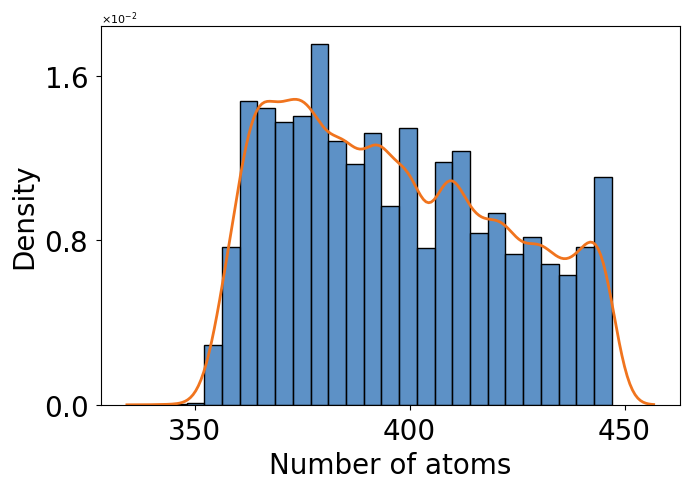

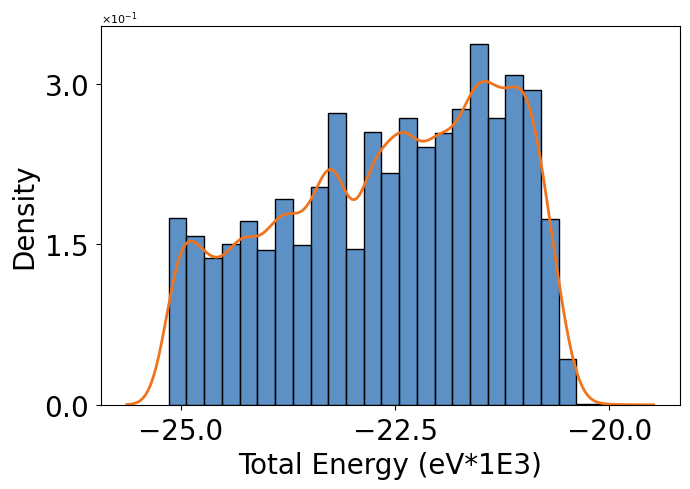

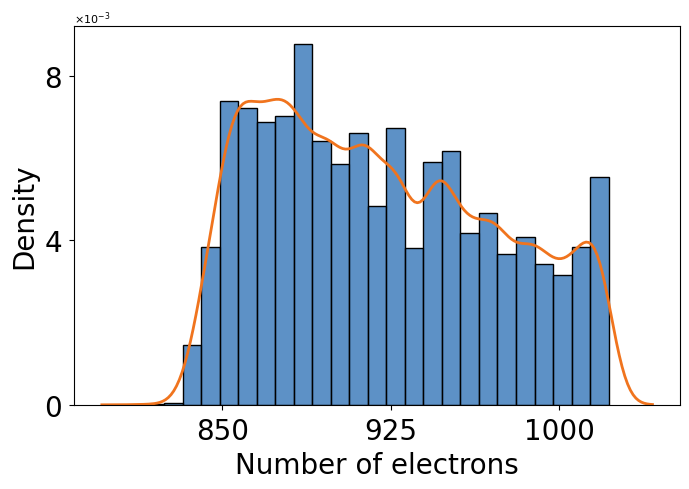

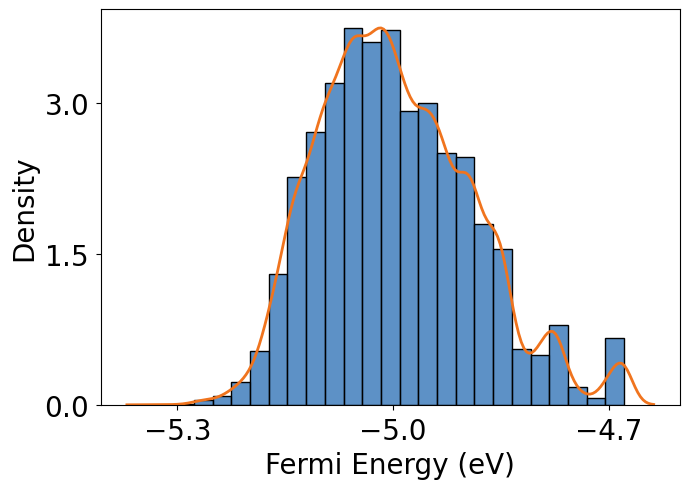

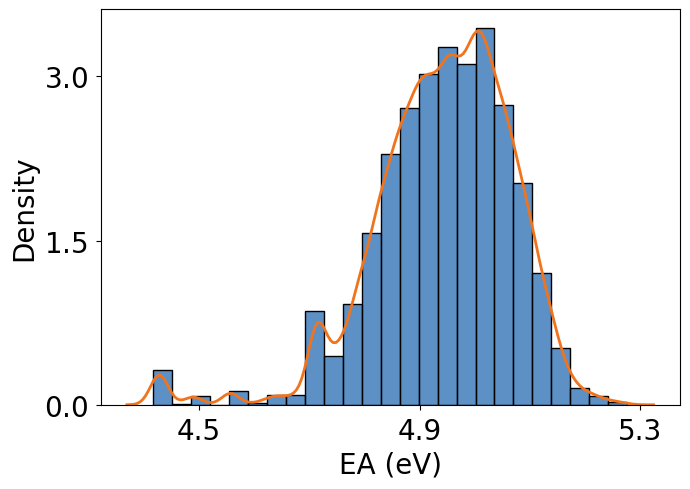

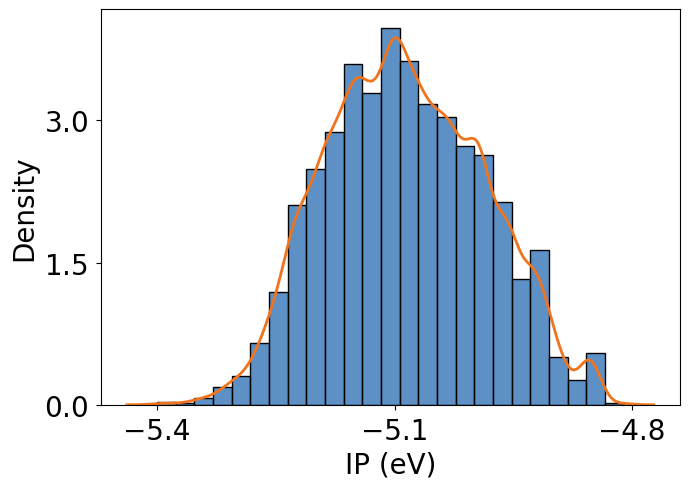

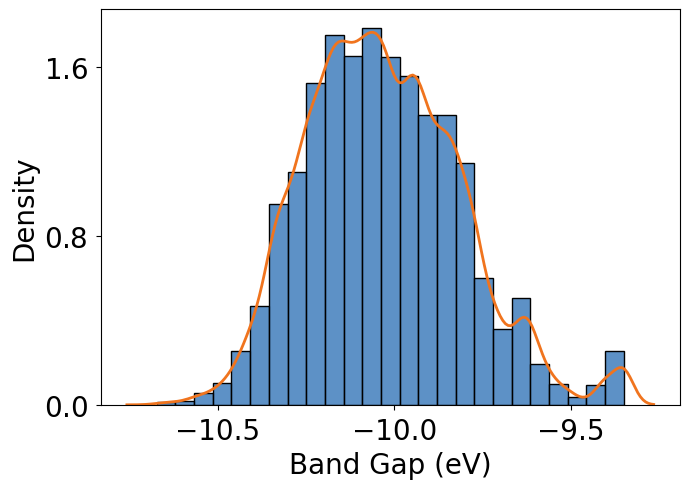

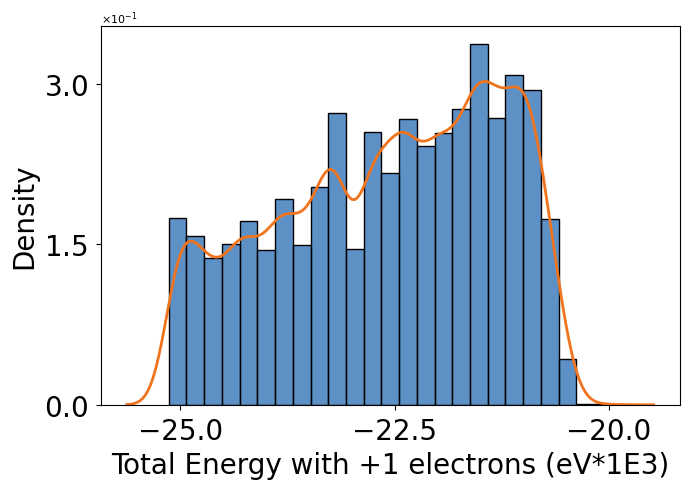

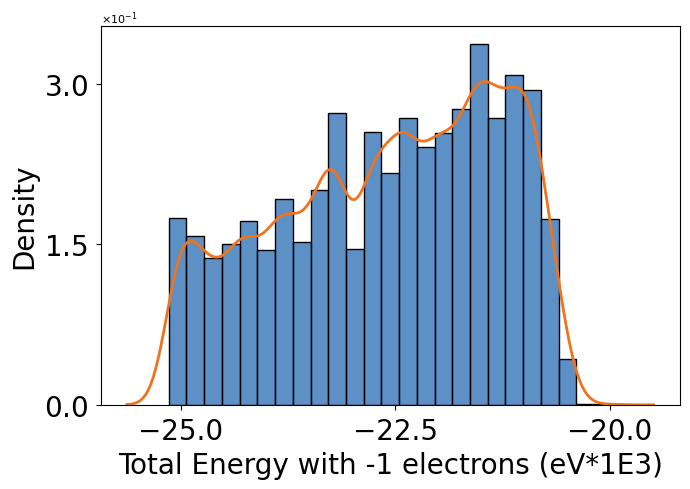

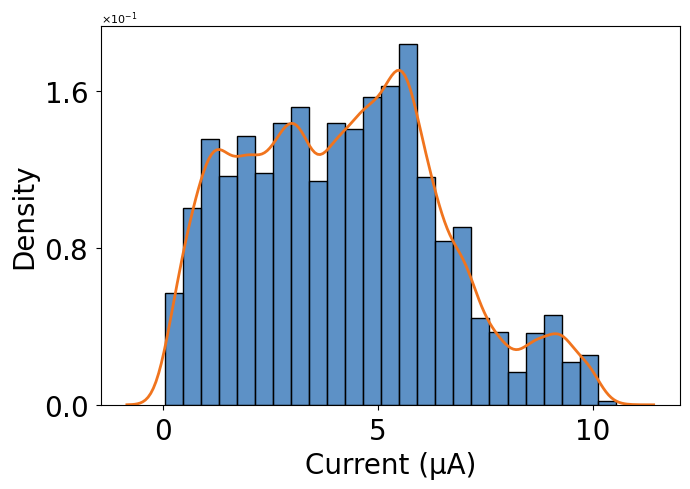

In [19]:
target_list = ["num_atoms","total_energy", "num_electrons", "Fermi_energy", "electron_affinity", "ionization_potential", "band_gap", "total_energy+1", "total_energy-1", "current"]
target_labels = {
    "num_atoms": ("Number of atoms", "Density"),
    "total_energy": ("Total Energy (eV*1E3)", "Density"),
    "num_electrons": (
        "Number of electrons",
        "Density",
    ),
    "Fermi_energy": ("Fermi Energy (eV)", "Density"),
    "electron_affinity": (
        "EA (eV)",
        "Density",
    ),
    "ionization_potential": (
        "IP (eV)",
        "Density",
    ),
    "band_gap": (
        "Band Gap (eV)",
        "Density",
    ),
    "total_energy+1": (
        "Total Energy with +1 electrons (eV*1E3)",
        "Density",
    ),
    "total_energy-1": (
        "Total Energy with -1 electrons (eV*1E3)",
        "Density",
    ),
    "current": (
        "Current (µA)",
        "Density",
    ),
}

target_ticks = {
    "num_atoms" : [350, 400, 450],
    "total_energy": [-25,-22.5,-20],
    "num_electrons": [850, 925, 1000],
    "Fermi_energy": [-5.3, -5.0, -4.7],
    "electron_affinity": [4.5, 4.9, 5.3],
    "ionization_potential": [-5.4, -5.1, -4.8],
    "band_gap": [-10.5, -10.0, -9.5],
    "total_energy+1": [-25,-22.5,-20],
    "total_energy-1": [-25,-22.5,-20],
    "current": [0,5,10],
}
df = pd.read_csv("./dataset.csv", header=0)

for target in target_list:
    
    if target == "current":
        df["current"] = df["current"]*1000000
    elif target == "total_energy":
        df["total_energy"] = df["total_energy"]/1000
    elif target == "total_energy+1":
        df["total_energy+1"] = df["total_energy+1"]/1000
    elif target == "total_energy-1":
        df["total_energy-1"] = df["total_energy-1"]/1000

    fig = plt.figure(figsize=(7, 5))

    ax = fig.add_subplot(1, 1, 1)  # Aggiungi subplot

    sns.histplot(
        x=df[f"{target}"],
        fill=True,
        linewidth=1,
        kde=False,
        stat="density",
        color=colors[1],
        ax=ax,
        bins=25 #int(np.sqrt(len(df[f"{target}"]))),
    )

    sns.kdeplot(x=df[f"{target}"], linewidth=2, color=colors[0], ax=ax)
    
    # Impostare i ticks in formato esponenziale
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1,1))

    #ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    # ax.xaxis.set_major_locator(
    #     MaxNLocator(nbins=3)
    # )  # Imposta massimo 3 ticks sull'asse x
    ax.set_xticks(target_ticks[target])
    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=3)
    )  # Imposta massimo 3 ticks sull'asse y
    ax.set_xlabel(target_labels[target][0], fontsize=20)
    ax.set_ylabel(target_labels[target][1], fontsize=20)
    plt.tick_params(axis="both", which="major", labelsize=20)
    plt.tight_layout()
    plt.savefig(
        save_path.joinpath(f"{target}.png"), dpi=300, bbox_inches="tight"
    )

/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/tommaso/miniconda3/envs/pl/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future versi

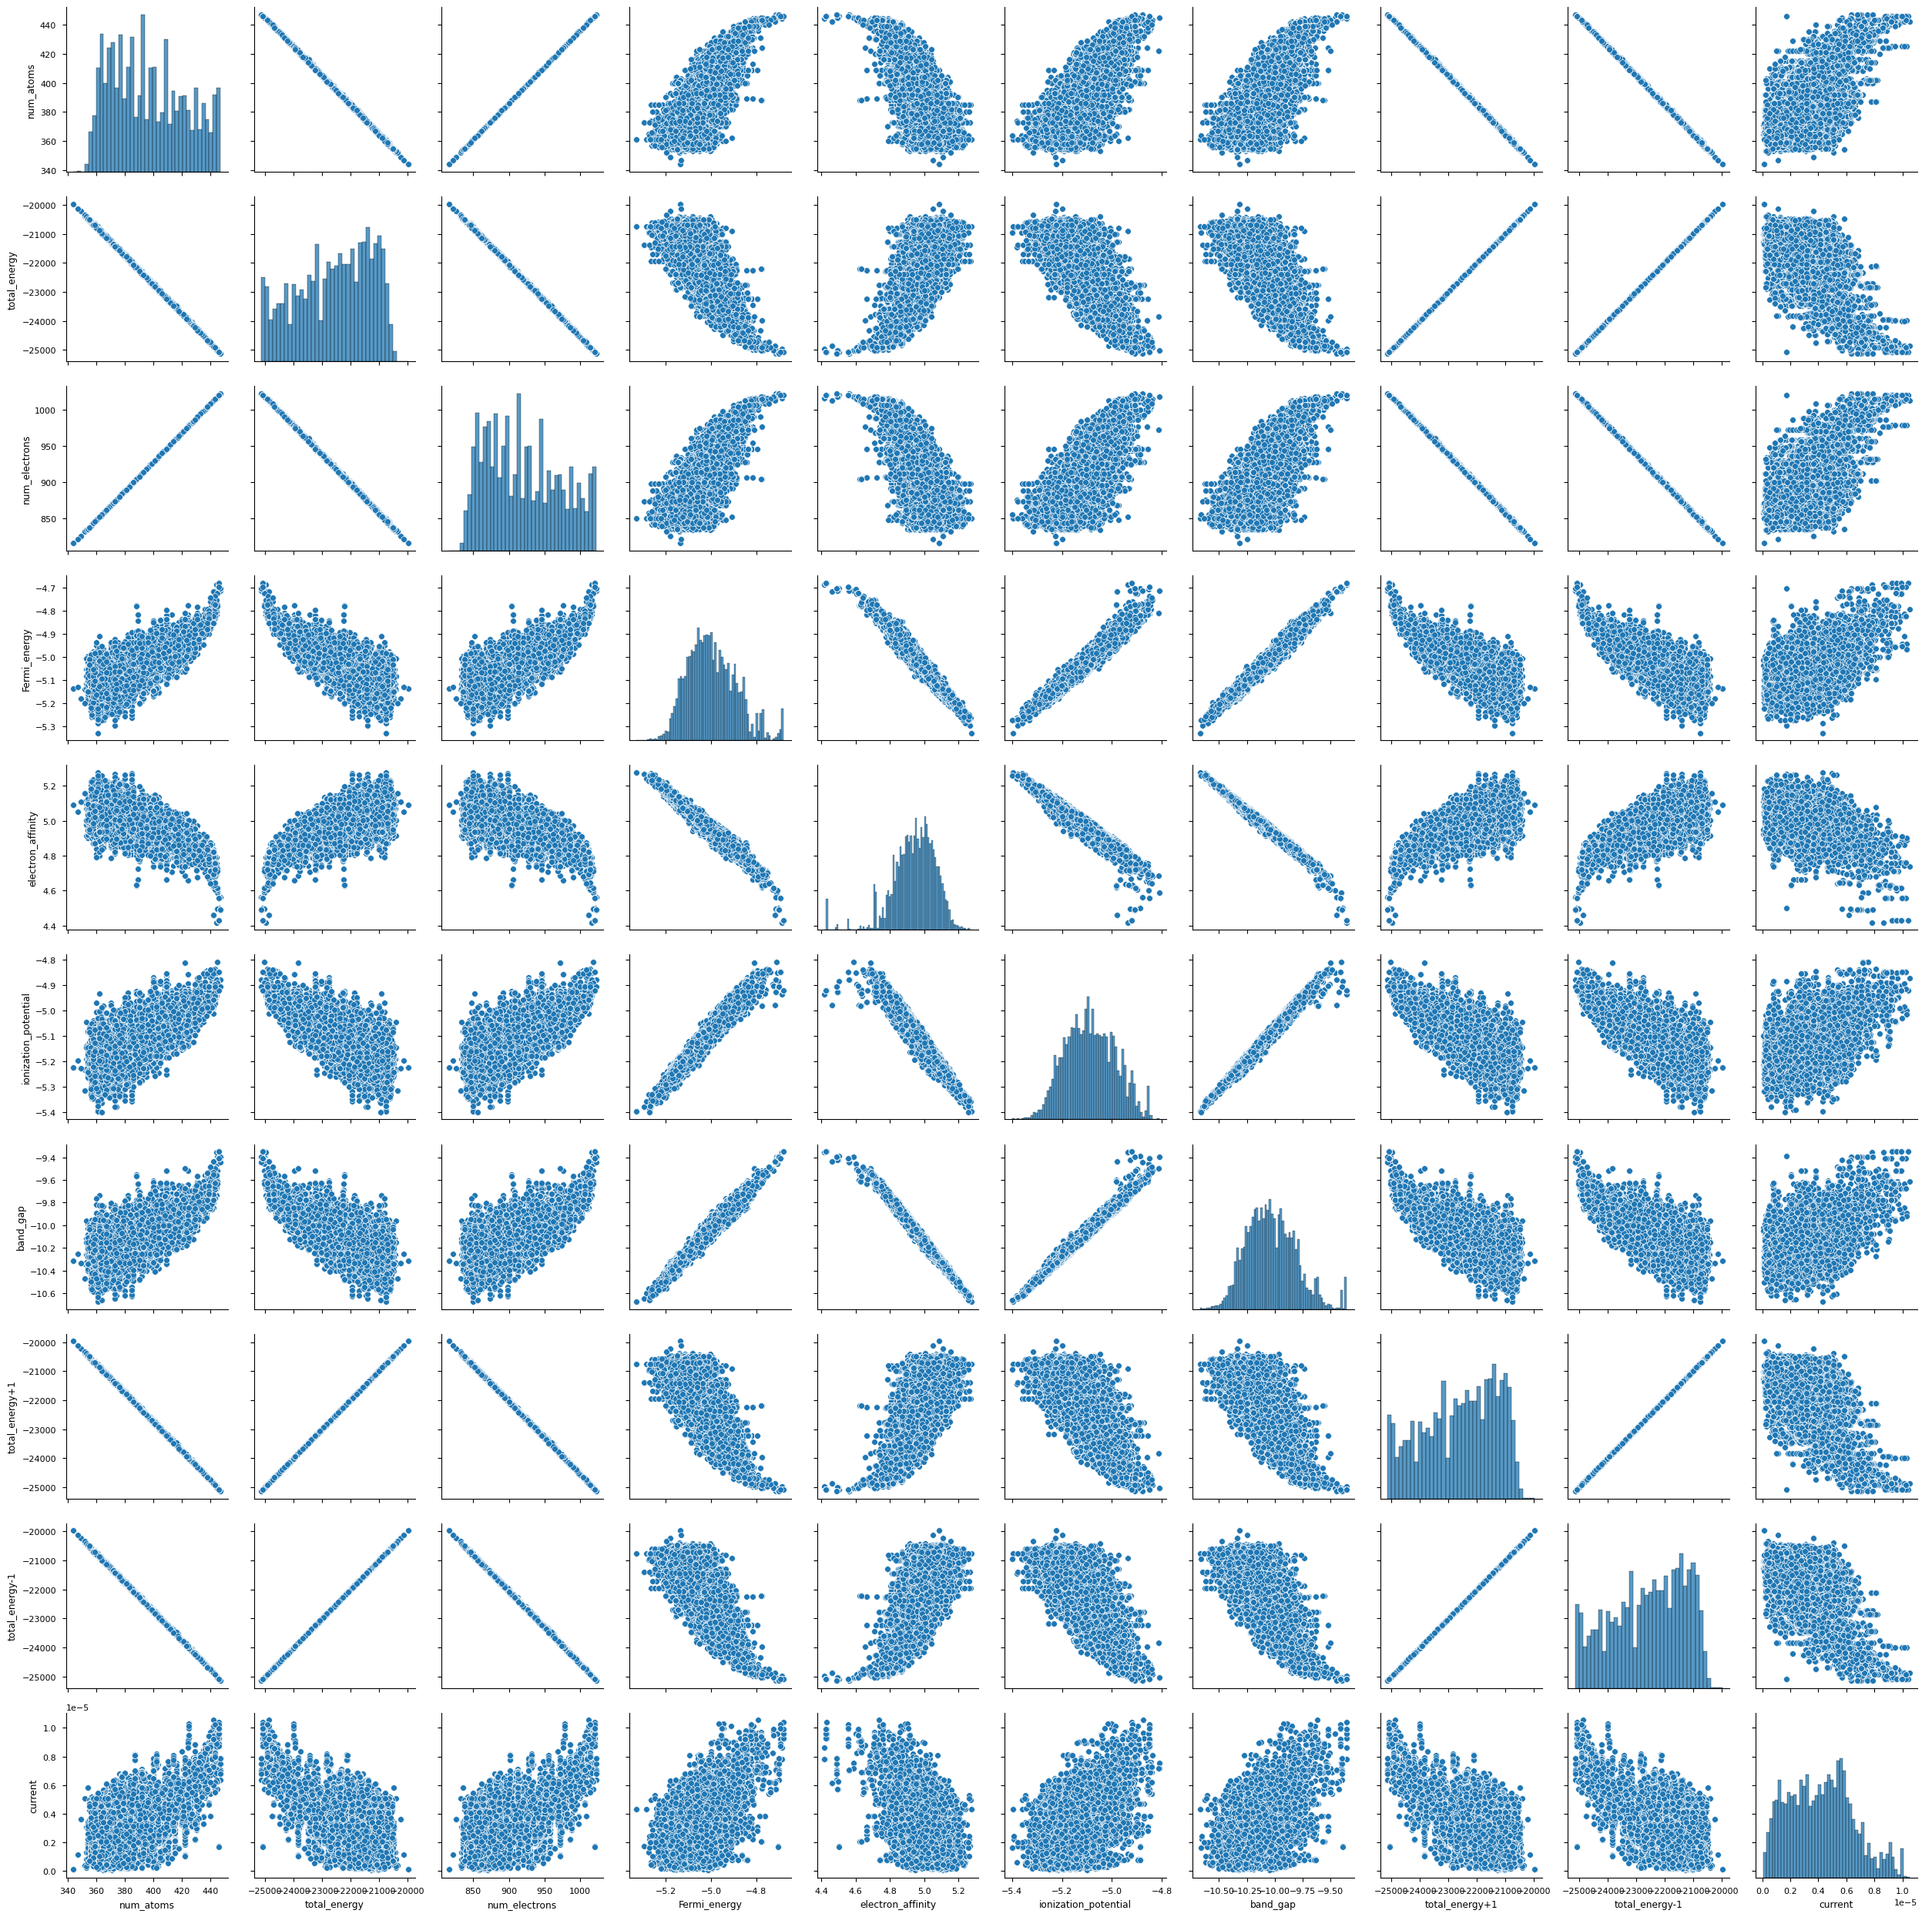

In [6]:
features_list = ["num_atoms","total_energy", "num_electrons", "Fermi_energy", "electron_affinity", "ionization_potential", "band_gap", "total_energy+1", "total_energy-1", "current"]
df = pd.read_csv("./dataset.csv", header=0)

pair_grid = sns.PairGrid(
    df, palette="tab10", vars=features_list
)  # Limita a prime 5 features per chiarezza
pair_grid.map_diag(sns.histplot)
pair_grid.map_offdiag(sns.scatterplot)
pair_grid.add_legend()
plt.tight_layout()
plt.savefig(
    save_path.joinpath("pairplot.png"), dpi=300, bbox_inches="tight"
)

In [4]:
df = pd.read_csv('./dataset.csv')

df.drop(
        ["file_name"], axis=1, inplace=True
    )

df["current"] = df["current"]*1000000

# Crea un dizionario per conservare i risultati
statistics = {
    'Mean': df.mean(),
    'Standard Deviation': df.std(),
    'Max': df.max(),
    'Min': df.min(),
    'Median': df.median(),
    '3rd Moment (Skewness)': df.apply(lambda x: skew(x.dropna())),
    '4th Moment (Kurtosis)': df.apply(lambda x: kurtosis(x.dropna(), fisher=False))
}

# Converti il dizionario in un DataFrame per visualizzare meglio i risultati
stats_df = pd.DataFrame(statistics)

# Stampa i risultati
print(stats_df)

                              Mean  Standard Deviation         Max  \
num_atoms               396.388485           25.589774    447.0000   
total_energy         -22582.835596         1278.776753 -19972.6437   
num_electrons           920.776969           51.179548   1022.0000   
Fermi_energy             -4.995634            0.108053     -4.6788   
electron_affinity         4.942445            0.126152      5.2762   
ionization_potential     -5.085947            0.099709     -4.8108   
band_gap                -10.028392            0.221841     -9.3501   
total_energy+1       -22577.749650         1278.856595 -19967.4195   
total_energy-1       -22587.778041         1278.681232 -19977.7328   
current                   4.197641            2.307233     10.5391   

                               Min       Median  3rd Moment (Skewness)  \
num_atoms               344.000000    393.00000               0.308030   
total_energy         -25138.182900 -22421.43305              -0.318476   
num_ele